In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import regionmask
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cmocean

from unseen import fileio

import utils

## Plot grid

In [2]:
infile = '/g/data/xv83/unseen-projects/outputs/bias/data/rx1day_AGCD-CSIRO_1901-2024_annual-jul-to-jun_AUS300i.nc'
ds = fileio.open_dataset(infile)
overlap_threshold = 0.67
shape_gpd = gpd.read_file('/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp')
shape_rgm = regionmask.from_geopandas(
    shape_gpd,
    names="AUS_NAME21",
    abbrevs="AUS_CODE21",
    name="australia"
)
frac = shape_rgm.mask_3D_frac_approx(ds)
mask = frac.sel(region=0) >= overlap_threshold

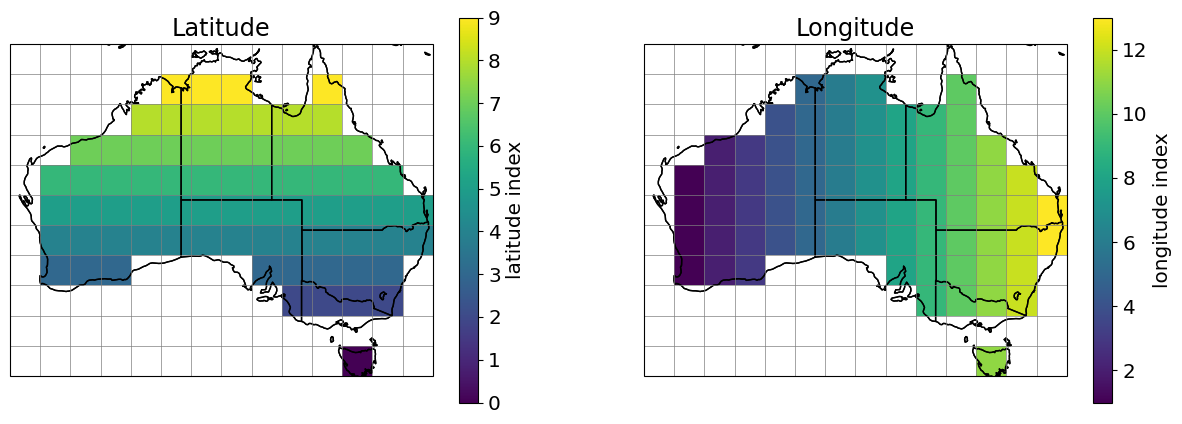

In [3]:
lon_array = xr.DataArray(
#    data=np.tile(mask.lon, (11, 1)),
    data=np.tile(np.arange(0,14), (11, 1)),
    coords={'lat': mask.lat, 'lon': mask.lon},
)

lat_array = xr.DataArray(
#    data=np.squeeze(np.dstack([mask.lat]*14)),
    data=np.squeeze(np.dstack([np.arange(0,11)]*14)),
    coords={'lat': mask.lat, 'lon': mask.lon},
) 

min_lat = mask.lat.values.min() - 1.5
max_lat = mask.lat.values.max() + 1.5
min_lon = mask.lon.values.min() - 1.5
max_lon = mask.lon.values.max() + 1.5

fig = plt.figure(figsize=[15, 5])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = lat_array.where(mask).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'latitude index'},
)
ax1.set_title('Latitude')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = lon_array.where(mask).plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'longitude index'},
)
ax2.set_title('Longitude')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

for lon in mask.lon.values:
    ax1.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([lon - 1.5, lon - 1.5], [min_lat, max_lat], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
for lat in mask.lat.values:
    ax1.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)
    ax2.plot([min_lon, max_lon], [lat - 1.5, lat - 1.5], transform=ccrs.PlateCarree(), color='0.5', lw=0.5)

plt.show()

## Plot rx1day data

In [4]:
return_period = 1000
infile = 'rx1day_spatial.nc'
ds_rx1day = xr.open_dataset(infile)

In [5]:
ds_rx1day

<xarray.Dataset> Size: 19kB
Dimensions:  (lev: 2, lat: 11, lon: 14)
Coordinates:
  * lev      (lev) int64 16B 100 1000
  * lat      (lat) float64 88B -42.0 -39.0 -36.0 -33.0 ... -18.0 -15.0 -12.0
  * lon      (lon) float64 112B 113.5 116.5 119.5 122.5 ... 146.5 149.5 152.5
Data variables:
    G2       (lev, lat, lon) float64 2kB ...
    M2       (lev, lat, lon) float64 2kB ...
    B2       (lev, lat, lon) float64 2kB ...
    T2       (lev, lat, lon) float64 2kB ...
    O2       (lev, lat, lon) float64 2kB ...
    MMM      (lev, lat, lon) float64 2kB ...
    obs      (lev, lat, lon) float64 2kB ...
    nmodels  (lat, lon) float64 1kB ...
Attributes:
    metric:   rx1day

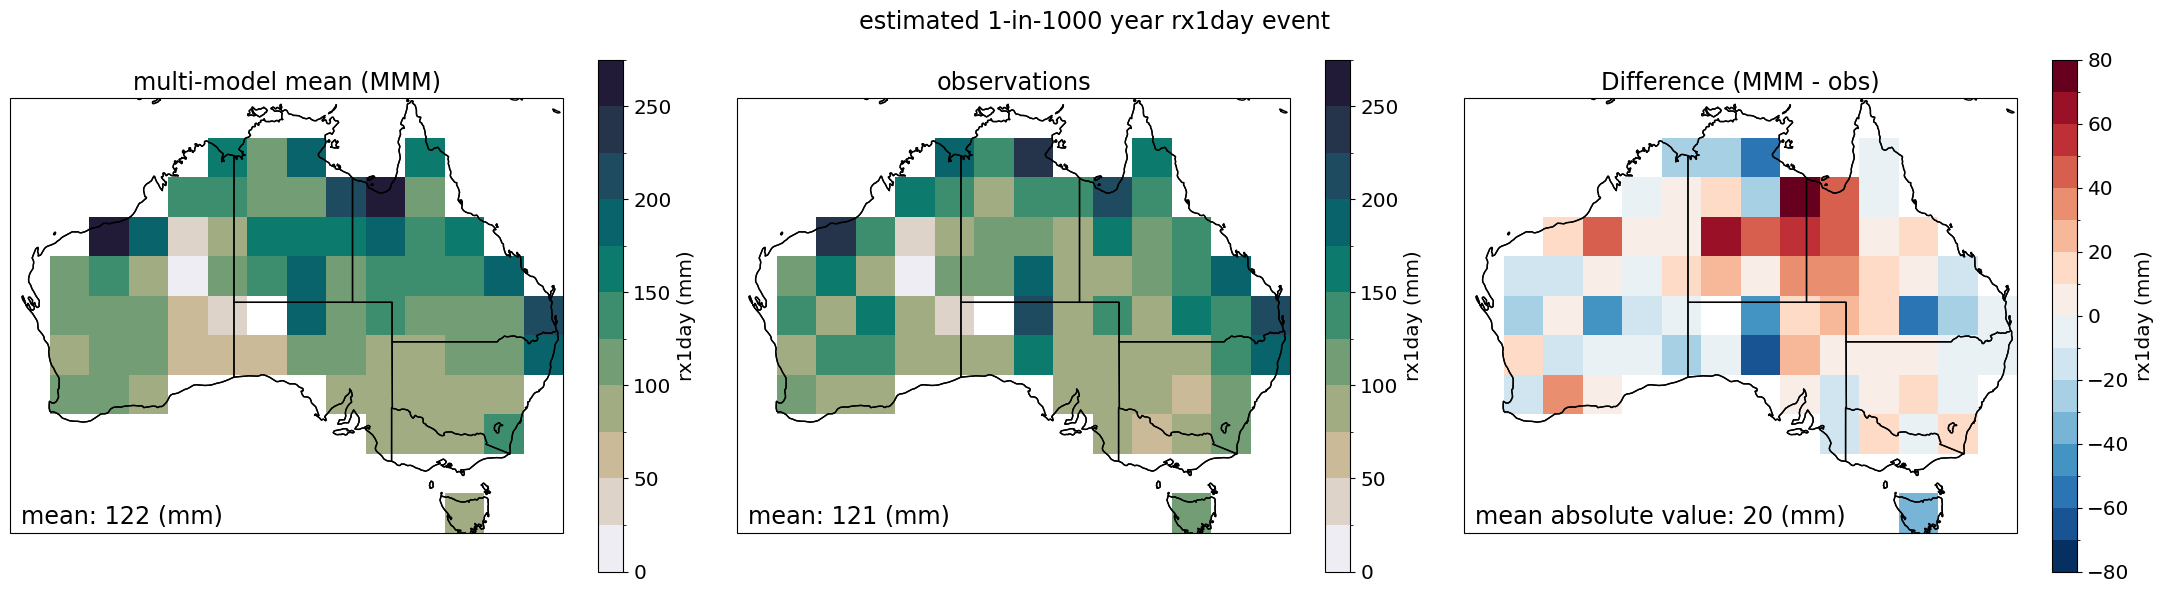

In [17]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_rx1day.sel({'lev': return_period})['MMM'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=np.arange(0, 276, 25),
    cmap=cmocean.cm.rain,
)
ax1.set_title('multi-model mean (MMM)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
mmm_mean = float(ds_rx1day.sel({'lev': return_period})['MMM'].mean())
ax1.text(0.02, 0.02, f'mean: {mmm_mean:.0f} (mm)', transform=ax1.transAxes, fontsize='xx-large')

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_rx1day.sel({'lev': return_period})['obs'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=np.arange(0, 276, 25),
    cmap=cmocean.cm.rain,
)
ax2.set_title('observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
obs_mean = float(ds_rx1day.sel({'lev': return_period})['obs'].mean())
ax2.text(0.02, 0.02, f'mean: {obs_mean:.0f} (mm)', transform=ax2.transAxes, fontsize='xx-large')

diff = ds_rx1day.sel({'lev': return_period})['MMM'] - ds_rx1day.sel({'lev': return_period})['obs']
ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = diff.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'rx1day (mm)'},
    levels=[-80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80],
    cmap='RdBu_r',
)
ax3.set_title('Difference (MMM - obs)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
diff_abs_mean = float(np.abs(diff).mean())
ax3.text(0.02, 0.02, f'mean absolute value: {diff_abs_mean:.0f} (mm)', transform=ax3.transAxes, fontsize='xx-large')

plt.suptitle(f'estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [18]:
ratio = ds_rx1day.sel({'lev': return_period})['T2'] / ds_rx1day.sel({'lev': return_period})['O2']

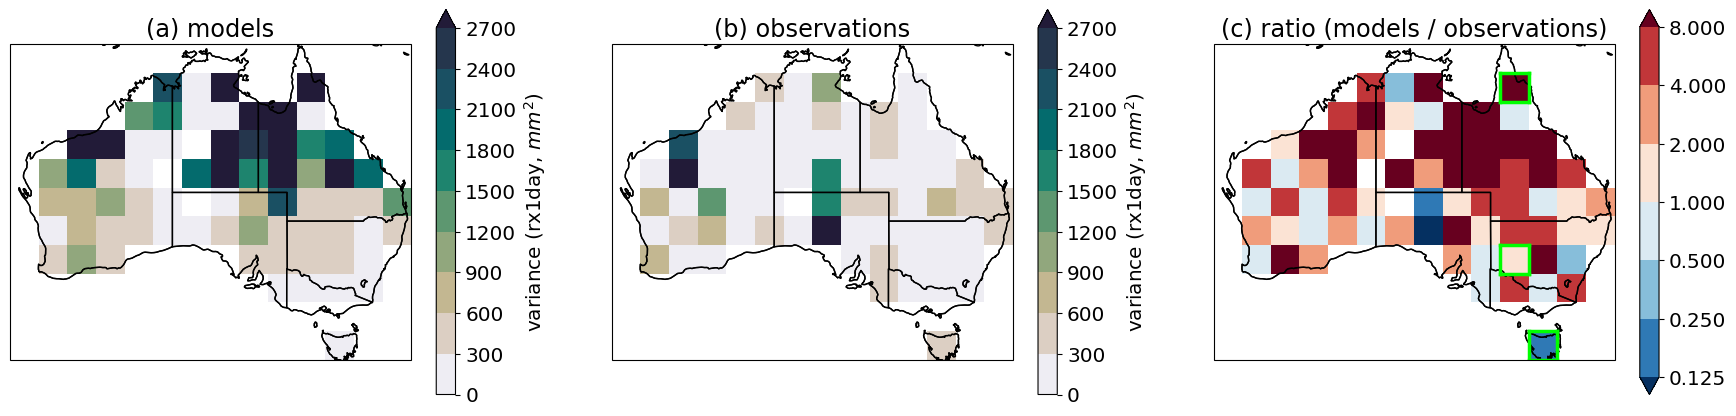

In [20]:
fig = plt.figure(figsize=[22, 5])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_rx1day.sel({'lev': return_period})['T2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 3000, 300),
    extend='max',
    cmap=cmocean.cm.rain,
)
ax1.set_title('(a) models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_rx1day.sel({'lev': return_period})['O2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (rx1day, $mm^2$)'},
    levels=np.arange(0, 3000, 300),
    extend='max',
    cmap=cmocean.cm.rain,
)
ax2.set_title('(b) observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
obs_mean = float(ds_rx1day.sel({'lev': return_period})['O2'].mean())

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ratio.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio (models / observations)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax3, 0, 11, color='lime')
utils.highlight_grid_box(ax3, 9, 10, color='lime')
utils.highlight_grid_box(ax3, 3, 10, color='lime')

#plt.suptitle(f'uncertainty in the estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.savefig('figures/rx1day_total_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

In [21]:
mmm_mean = float(ds_rx1day.sel({'lev': return_period})['T2'].mean())
obs_mean = float(ds_rx1day.sel({'lev': return_period})['O2'].mean())
mean_ratio = mmm_mean / obs_mean

print(f'MMM mean uncertainty: {mmm_mean:.1f} mm^2')
print(f'Obs mean uncertainty: {obs_mean:.1f} mm^2')
print(f'Ratio: {mean_ratio:.2f}')

MMM mean uncertainty: 1541.4 mm^2
Obs mean uncertainty: 416.9 mm^2
Ratio: 3.70


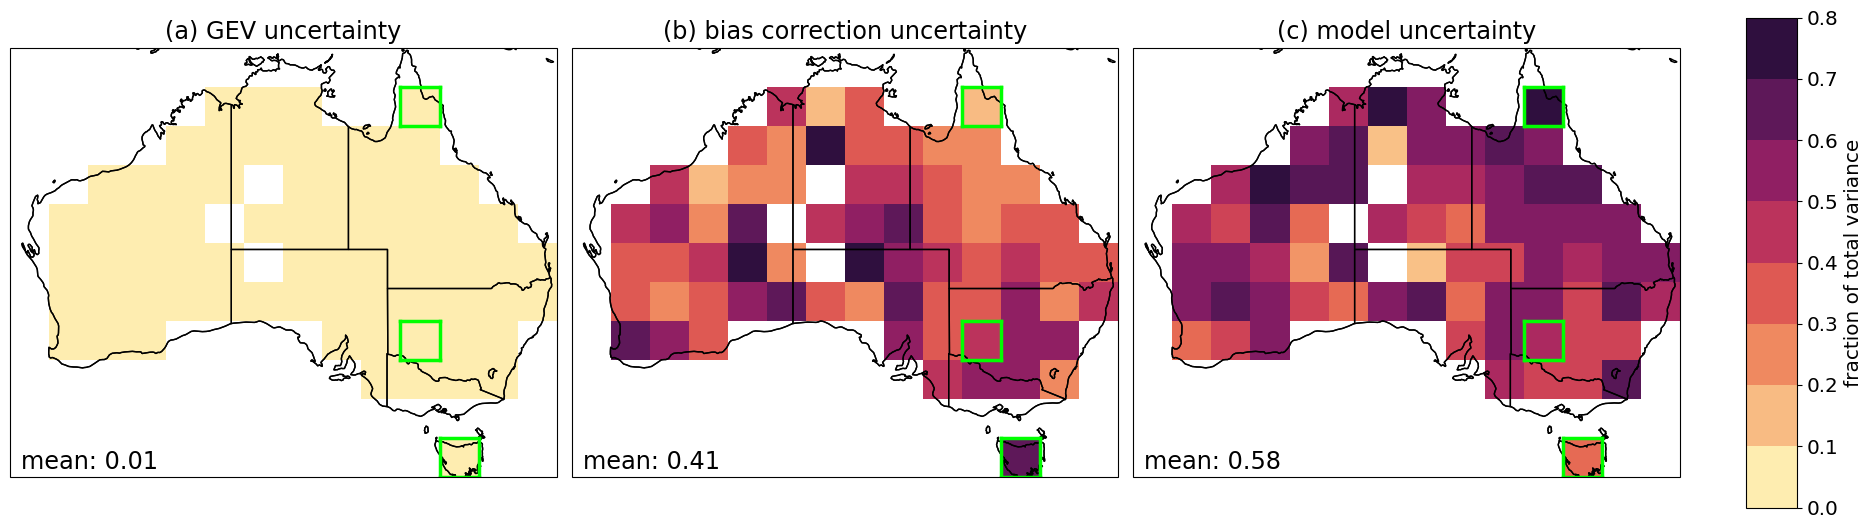

In [27]:
fig = plt.figure(figsize=[17, 7])
cbar_levels = np.arange(0, 0.81, 0.1)
cmap = cmocean.cm.matter

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
g_frac = ds_rx1day.sel({'lev': return_period})['G2'] / ds_rx1day.sel({'lev': return_period})['T2']
im1 = g_frac.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('(a) GEV uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
g_mean = float(g_frac.mean())
ax1.text(0.02, 0.02, f'mean: {g_mean:.2f}', transform=ax1.transAxes, fontsize='xx-large')

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
b_frac = ds_rx1day.sel({'lev': return_period})['B2'] / ds_rx1day.sel({'lev': return_period})['T2']
im2 = b_frac.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('(b) bias correction uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
b_mean = float(b_frac.mean())
ax2.text(0.02, 0.02, f'mean: {b_mean:.2f}', transform=ax2.transAxes, fontsize='xx-large')

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
m_frac = ds_rx1day.sel({'lev': return_period})['M2'] / ds_rx1day.sel({'lev': return_period})['T2']
im3 = m_frac.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('(c) model uncertainty')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
m_mean = float(m_frac.mean())
ax3.text(0.02, 0.02, f'mean: {m_mean:.2f}', transform=ax3.transAxes, fontsize='xx-large')

utils.highlight_grid_box(ax1, 0, 11, color='lime')
utils.highlight_grid_box(ax2, 0, 11, color='lime')
utils.highlight_grid_box(ax3, 0, 11, color='lime')
utils.highlight_grid_box(ax1, 9, 10, color='lime')
utils.highlight_grid_box(ax2, 9, 10, color='lime')
utils.highlight_grid_box(ax3, 9, 10, color='lime')
utils.highlight_grid_box(ax1, 3, 10, color='lime')
utils.highlight_grid_box(ax2, 3, 10, color='lime')
utils.highlight_grid_box(ax3, 3, 10, color='lime')

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='fraction of total variance')

#plt.suptitle(f' uncertainty in the estimated 1-in-{return_period} year rx1day event', fontsize='xx-large')
plt.tight_layout()
plt.savefig('figures/rx1day_component_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

In [28]:
g_max = float(g_frac.max())
g_mean = float(g_frac.mean())
g_min = float(g_frac.min())

print(f'GEV uncertainty maximum: {g_max:.3f}')
print(f'GEV uncertainty mean: {g_mean:.3f}')
print(f'GEV uncertainty minimum: {g_min:.3f}')

GEV uncertainty maximum: 0.071
GEV uncertainty mean: 0.009
GEV uncertainty minimum: 0.001


In [29]:
b_max = float(b_frac.max())
b_mean = float(b_frac.mean())
b_min = float(b_frac.min())

print(f'bias correction uncertainty maximum: {b_max:.2f}')
print(f'bias correction uncertainty mean: {b_mean:.2f}')
print(f'bias correction uncertainty minimum: {b_min:.2f}')

bias correction uncertainty maximum: 0.78
bias correction uncertainty mean: 0.41
bias correction uncertainty minimum: 0.16


In [30]:
m_max = float(m_frac.max())
m_mean = float(m_frac.mean())
m_min = float(m_frac.min())

print(f'model uncertainty maximum: {m_max:.2f}')
print(f'model uncertainty mean: {m_mean:.2f}')
print(f'model uncertainty minimum: {m_min:.2f}')

model uncertainty maximum: 0.84
model uncertainty mean: 0.58
model uncertainty minimum: 0.18


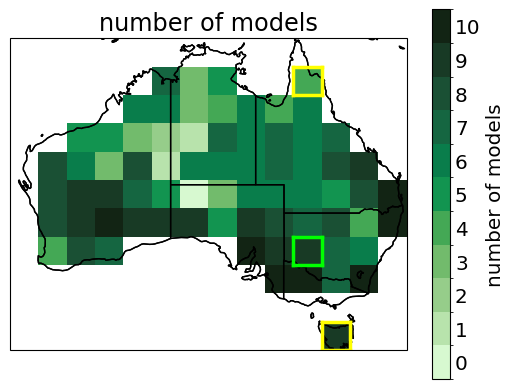

In [26]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ds_rx1day['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('number of models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar.ax.tick_params(size=0)

utils.highlight_grid_box(ax1, 0, 11, color='lime')
utils.highlight_grid_box(ax1, 9, 10, color='lime')
utils.highlight_grid_box(ax1, 3, 10, color='lime')

plt.show()

## Plot txx data

In [31]:
return_period = 1000
infile = 'txx_spatial.nc'
ds_txx = xr.open_dataset(infile)

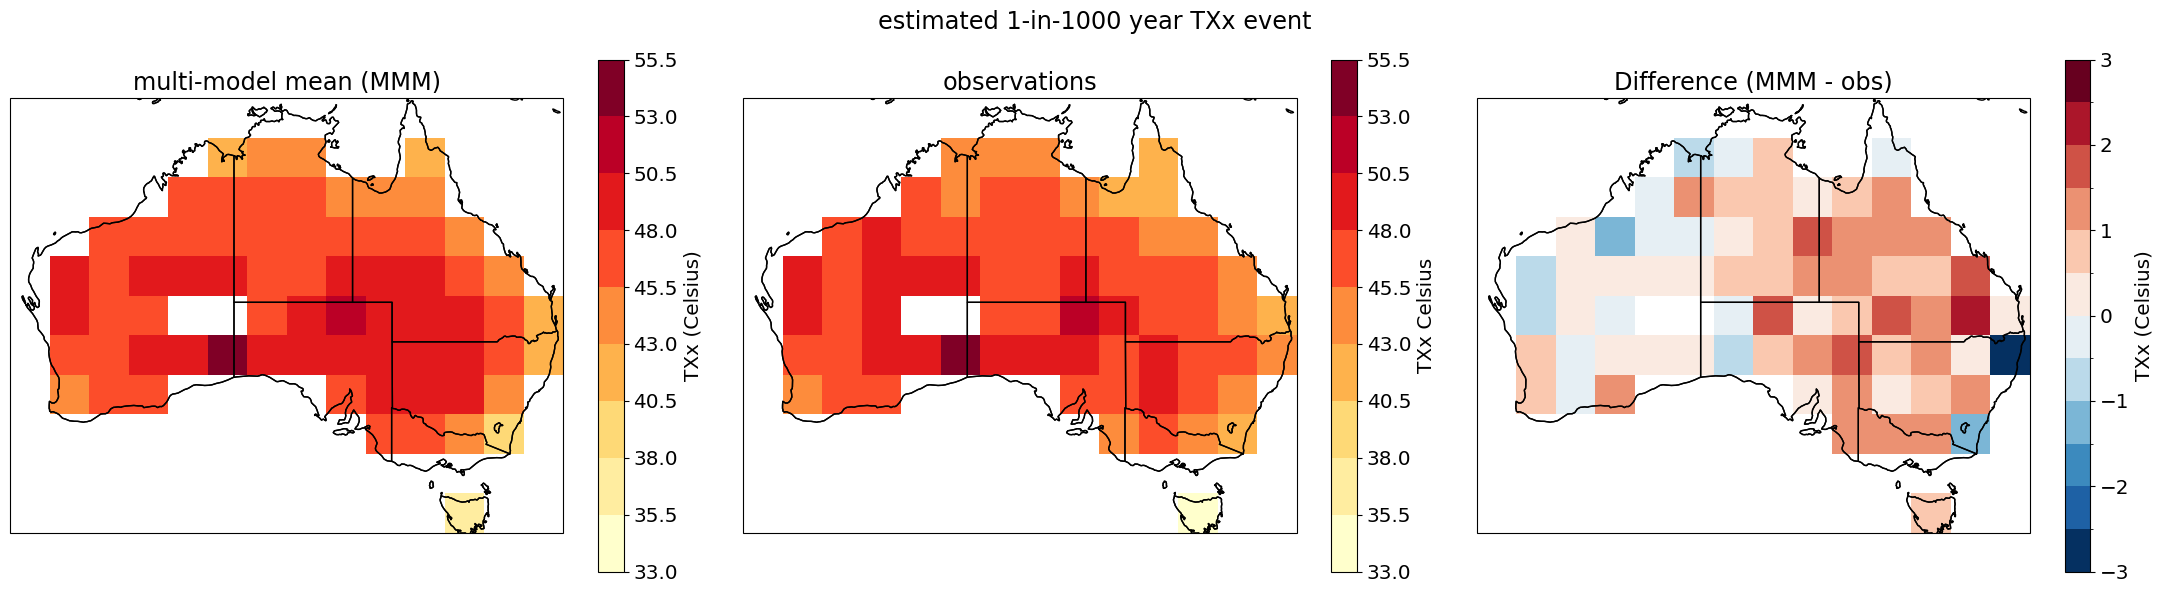

In [33]:
fig = plt.figure(figsize=[22, 6])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_txx.sel({'lev': return_period})['MMM'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx (Celsius)'},
    levels=np.arange(33, 56, 2.5),
    cmap='YlOrRd',
)
ax1.set_title('multi-model mean (MMM)')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_txx.sel({'lev': return_period})['obs'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx Celsius'},
    levels=np.arange(33, 56, 2.5),
    cmap='YlOrRd',
)
ax2.set_title('observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

diff = ds_txx.sel({'lev': return_period})['MMM'] - ds_txx.sel({'lev': return_period})['obs']
ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = diff.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'TXx (Celsius)'},
    levels=[-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
    cmap='RdBu_r',
)
ax3.set_title('Difference (MMM - obs)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

plt.suptitle(f'estimated 1-in-{return_period} year TXx event', fontsize='xx-large')
plt.tight_layout()
plt.show()

In [35]:
diff_abs_mean = float(np.abs(diff).mean())

mmm_mean = float(ds_txx.sel({'lev': return_period})['MMM'].mean())
obs_mean = float(ds_txx.sel({'lev': return_period})['obs'].mean())

print(f'MMM mean: {mmm_mean:.1f} C')
print(f'Obs mean: {obs_mean:.1f} C')
print(f'Mean absolute difference: {diff_abs_mean:.1f} C')

MMM mean: 46.9 C
Obs mean: 46.4 C
Mean absolute difference: 0.8 C


In [36]:
ratio = ds_txx.sel({'lev': return_period})['T2'] / ds_txx.sel({'lev': return_period})['O2']

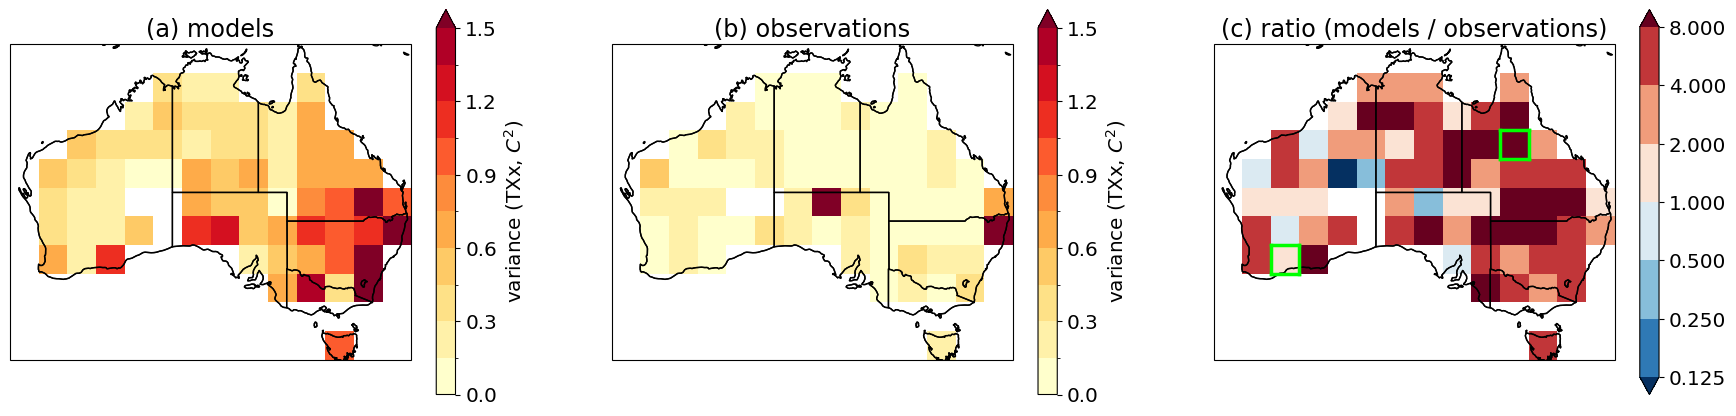

In [38]:
fig = plt.figure(figsize=[22, 5])

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
im1 = ds_txx.sel({'lev': return_period})['T2'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax1.set_title('(a) models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
im2 = ds_txx.sel({'lev': return_period})['O2'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'variance (TXx, $C^2$)'},
    levels=np.arange(0, 1.51, 0.15),
    extend='max',
    cmap='YlOrRd',
)
ax2.set_title('(b) observations')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
im3 = ratio.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    levels=[1/8, 1/4, 1/2, 1, 2, 4, 8],
    extend='both',
    cmap='RdBu_r'
)
ax3.set_title('(c) ratio (models / observations)')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)

utils.highlight_grid_box(ax3, 7, 10, color='lime')
utils.highlight_grid_box(ax3, 3, 2, color='lime')

#plt.suptitle(f'uncertainty in the estimated 1-in-{return_period} year TXx event', fontsize='xx-large')
plt.savefig('figures/txx_total_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

In [39]:
mmm_mean = float(ds_txx.sel({'lev': return_period})['T2'].mean())
obs_mean = float(ds_txx.sel({'lev': return_period})['O2'].mean())
mean_ratio = mmm_mean / obs_mean

print(f'MMM mean uncertainty: {mmm_mean:.1f} C^2')
print(f'Obs mean uncertainty: {obs_mean:.1f} C^2')
print(f'Ratio: {mean_ratio:.2f}')

MMM mean uncertainty: 0.7 C^2
Obs mean uncertainty: 0.2 C^2
Ratio: 3.45


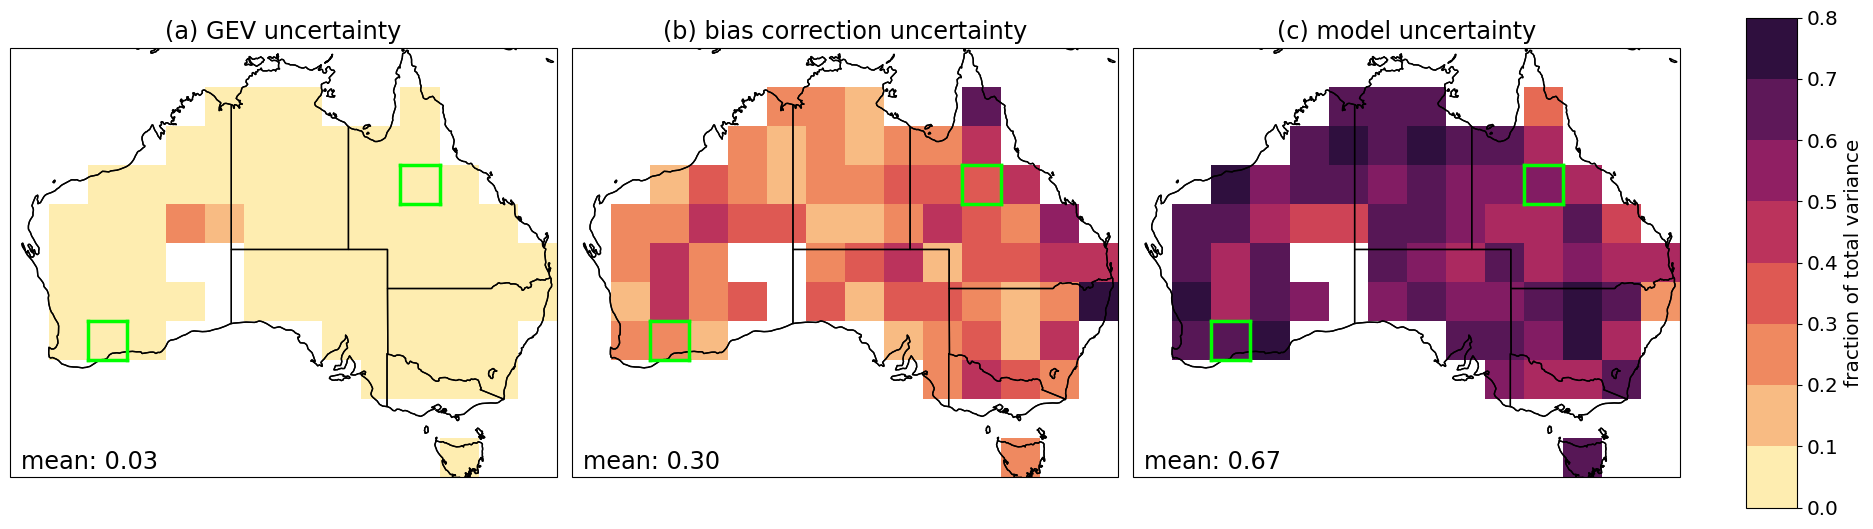

In [42]:
fig = plt.figure(figsize=[17, 7])
cbar_levels = np.arange(0, 0.81, 0.1)
cmap = cmocean.cm.matter

ax1 = fig.add_subplot(131, projection=ccrs.PlateCarree())
g_frac = ds_txx.sel({'lev': return_period})['G2'] / ds_txx.sel({'lev': return_period})['T2'] 
im1 = g_frac.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax1.set_title('(a) GEV uncertainty')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
g_mean = float(g_frac.mean())
ax1.text(0.02, 0.02, f'mean: {g_mean:.2f}', transform=ax1.transAxes, fontsize='xx-large')

ax2 = fig.add_subplot(132, projection=ccrs.PlateCarree())
b_frac = ds_txx.sel({'lev': return_period})['B2'] / ds_txx.sel({'lev': return_period})['T2']
im2 = b_frac.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax2.set_title('(b) bias correction uncertainty')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)
b_mean = float(b_frac.mean())
ax2.text(0.02, 0.02, f'mean: {b_mean:.2f}', transform=ax2.transAxes, fontsize='xx-large')

ax3 = fig.add_subplot(133, projection=ccrs.PlateCarree())
m_frac = ds_txx.sel({'lev': return_period})['M2'] / ds_txx.sel({'lev': return_period})['T2']
im3 = m_frac.plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    levels=cbar_levels,
    cmap=cmap,
)
ax3.set_title('(c) model uncertainty')
ax3.coastlines()
ax3.add_feature(cartopy.feature.STATES)
m_mean = float(m_frac.mean())
ax3.text(0.02, 0.02, f'mean: {m_mean:.2f}', transform=ax3.transAxes, fontsize='xx-large')

cbar_ax = fig.add_axes([1.03, 0.15, 0.03, 0.7]) # left, bottom, width, height
fig.colorbar(im1, cax=cbar_ax, label='fraction of total variance')

utils.highlight_grid_box(ax1, 3, 2, color='lime')
utils.highlight_grid_box(ax2, 3, 2, color='lime')
utils.highlight_grid_box(ax3, 3, 2, color='lime')

utils.highlight_grid_box(ax1, 7, 10, color='lime')
utils.highlight_grid_box(ax2, 7, 10, color='lime')
utils.highlight_grid_box(ax3, 7, 10, color='lime')

#plt.suptitle(f' uncertainty in the estimated 1-in-{return_period} year Txx event', fontsize='xx-large')
plt.savefig('figures/txx_component_uncertainty_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.tight_layout()
plt.show()

In [43]:
g_max = float(g_frac.max())
g_mean = float(g_frac.mean())
g_min = float(g_frac.min())

print(f'GEV uncertainty maximum: {g_max:.3f}')
print(f'GEV uncertainty mean: {g_mean:.3f}')
print(f'GEV uncertainty minimum: {g_min:.3f}')

GEV uncertainty maximum: 0.253
GEV uncertainty mean: 0.027
GEV uncertainty minimum: 0.003


In [44]:
b_max = float(b_frac.max())
b_mean = float(b_frac.mean())
b_min = float(b_frac.min())

print(f'bias correction uncertainty maximum: {b_max:.2f}')
print(f'bias correction uncertainty mean: {b_mean:.2f}')
print(f'bias correction uncertainty minimum: {b_min:.2f}')

bias correction uncertainty maximum: 0.73
bias correction uncertainty mean: 0.30
bias correction uncertainty minimum: 0.12


In [45]:
m_max = float(m_frac.max())
m_mean = float(m_frac.mean())
m_min = float(m_frac.min())

print(f'model uncertainty maximum: {m_max:.2f}')
print(f'model uncertainty mean: {m_mean:.2f}')
print(f'model uncertainty minimum: {m_min:.2f}')

model uncertainty maximum: 0.87
model uncertainty mean: 0.67
model uncertainty minimum: 0.26


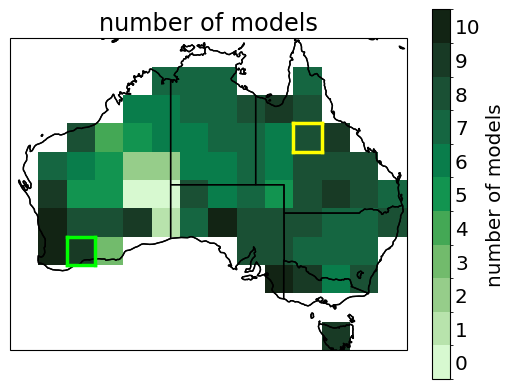

In [39]:
fig = plt.figure()#figsize=[5, 5])

ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
im1 = ds_txx['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('number of models')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar.ax.tick_params(size=0)

utils.highlight_grid_box(ax1, 7, 10, color='lime')
utils.highlight_grid_box(ax1, 3, 2, color='lime')

plt.show()

## Both

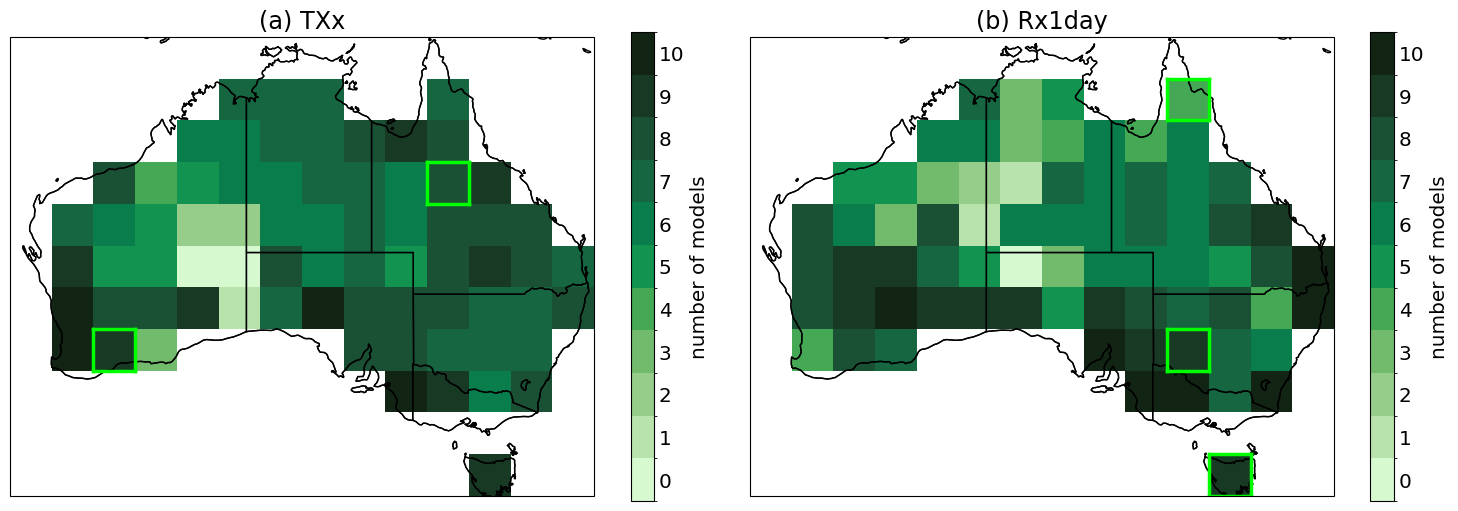

In [58]:
fig = plt.figure(figsize=[15, 5])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
im1 = ds_txx['nmodels'].plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax1.set_title('(a) TXx')
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)

cbar1 = fig.colorbar(im1, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar1.ax.tick_params(size=0)

utils.highlight_grid_box(ax1, 7, 10, color='lime')
utils.highlight_grid_box(ax1, 3, 2, color='lime')

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
im2 = ds_rx1day['nmodels'].plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
#    cbar_kwargs={'label': ' '},
    levels=np.arange(-0.5, 10.6, 1.0),
#    extend='min',
    cmap=cmocean.cm.algae
)
ax2.set_title('(b) Rx1day')
ax2.coastlines()
ax2.add_feature(cartopy.feature.STATES)

cbar2 = fig.colorbar(im2, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], label='number of models')
cbar2.ax.tick_params(size=0)

utils.highlight_grid_box(ax2, 0, 11, color='lime')
utils.highlight_grid_box(ax2, 9, 10, color='lime')
utils.highlight_grid_box(ax2, 3, 10, color='lime')
plt.tight_layout()
plt.savefig('figures/nmodels_map.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()